# Caro ResNet


In [1]:
import torch
from torch import nn


In [2]:
BOARD_SIZE = 15
INPUT_CHANNELS = 3

In [3]:
# Cấu hình dễ tinh chỉnh
MODEL_CHANNELS = 64
MODEL_BLOCKS = 10
LEARNING_RATE = 1e-3

TRAIN_STEPS = 1000
TRAIN_MAX_MOVES = 100
PRINT_EVERY = 1

FUTURE_STEPS = 10
GAMMA = 0.8
OWN_FUTURE_WEIGHT = 1.0
ENEMY_FUTURE_WEIGHT = 0.8

REWARD_ALPHA = 8.0
INVALID_LOSS = None
WIN_REWARD = None

VISUAL_MAX_MOVES = 120
VISUAL_PAUSE = 0.25


## ResidualBlock


In [4]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        residual = x
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        
        x = self.conv2(x)
        x = self.bn2(x)
        
        x = x + residual
        x = self.relu(x)
        return x


## Model chính


In [5]:
class CaroResNet(nn.Module):
    def __init__(self, input_channels=3, channels=32, num_blocks=20):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(input_channels, channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
        )
        self.blocks = nn.Sequential(
            *[ResidualBlock(channels) for _ in range(num_blocks)]
        )
        self.policy_head = nn.Conv2d(channels, 1, kernel_size=1)

    def forward(self, board):
        x = self.stem(board)
        x = self.blocks(x)
        x = self.policy_head(x)
        return x.squeeze(1)


## Input mẫu 3 kênh


In [6]:
# channel 0: our stones
# channel 1: enemy stones
# channel 2: legal cells
board = torch.zeros(1, INPUT_CHANNELS, BOARD_SIZE, BOARD_SIZE)
board[:, 2, :, :] = 1

board[0, 0, 7, 7] = 1
board[0, 2, 7, 7] = 0

board[0, 1, 7, 8] = 1
board[0, 2, 7, 8] = 0

board.shape


torch.Size([1, 3, 15, 15])

In [7]:
model = CaroResNet(
    input_channels=INPUT_CHANNELS,
    channels=MODEL_CHANNELS,
    num_blocks=MODEL_BLOCKS,
)

scores = model(board)
probabilities = torch.softmax(scores.flatten(start_dim=1), dim=1).reshape(-1, BOARD_SIZE, BOARD_SIZE)

print("Input shape :", board.shape)
print("Scores shape:", scores.shape)
print("Prob shape  :", probabilities.shape)
print("Prob sum   :", probabilities.sum(dim=(1, 2)))
print("số tham số của mô hình:", sum(p.numel() for p in model.parameters()))


Input shape : torch.Size([1, 3, 15, 15])
Scores shape: torch.Size([1, 15, 15])
Prob shape  : torch.Size([1, 15, 15])
Prob sum   : tensor([1.], grad_fn=<SumBackward1>)
số tham số của mô hình: 741761


## Loss tự chơi


In [8]:
def window_reward(board_t, row, col, alpha=REWARD_ALPHA, win_reward=WIN_REWARD):
    """
    Tính điểm thưởng cho một ô nếu ta giả sử sẽ đánh vào ô đó. 

    board_t: trạng thái bàn cờ tại một bước, shape (3, 15, 15).
        board_t[0]: các ô đang có quân ta.
        board_t[1]: các ô đang có quân địch.
        board_t[2]: các ô còn hợp lệ để đánh.
    row, col: tọa độ ô đang xét.
    alpha: hệ số tăng thưởng theo số quân trong một cửa sổ 5 ô.
    win_reward: thưởng rất lớn nếu nước này tạo thành 5 quân.
    """
    if win_reward is None:
        win_reward = alpha ** 6

    our = board_t[0]
    enemy = board_t[1]
    legal = board_t[2]
    board_size = board_t.shape[-1]

    # Bốn hướng cần xét trong caro: dọc, ngang, chéo xuống, chéo lên.
    directions = [(1, 0), (0, 1), (1, 1), (1, -1)]

    # Tổng thưởng của tất cả cửa sổ 5 ô có đè lên ô (row, col).
    total_reward = torch.zeros((), device=board_t.device)

    for dr, dc in directions:
        # Một ô có thể nằm ở 5 vị trí khác nhau trong một cửa sổ dài 5.
        for offset in range(5):
            start_row = row - offset * dr
            start_col = col - offset * dc

            cells = []
            valid_window = True

            # Tạo danh sách 5 ô của cửa sổ hiện tại.
            for k in range(5):
                r = start_row + k * dr
                c = start_col + k * dc

                # Nếu cửa sổ vượt ra ngoài bàn cờ thì bỏ qua.
                if not (0 <= r < board_size and 0 <= c < board_size):
                    valid_window = False
                    break

                cells.append((r, c))

            if not valid_window:
                continue

            our_count = 0
            enemy_count = 0
            has_wall = False

            # Đếm quân ta/quân địch trong cửa sổ.
            for r, c in cells:
                # Ô đang xét là ô ta định đánh, nên không tính là ô trống nữa.
                if r == row and c == col:
                    continue

                if our[r, c] > 0.5:
                    our_count += 1
                elif enemy[r, c] > 0.5:
                    enemy_count += 1
                elif legal[r, c] <= 0.5:
                    # Không phải quân ta, không phải quân địch, nhưng cũng không hợp lệ.
                    # Ta xem nó như tường/chướng ngại nên cửa sổ này không có thưởng.
                    has_wall = True

            if has_wall:
                continue
            if our_count > 0 and enemy_count > 0:
                continue
            if our_count == 4:
                total_reward = total_reward + win_reward
            elif our_count > 0:
                total_reward = total_reward + (alpha ** our_count)
            elif enemy_count > 0:
                total_reward = total_reward + (alpha ** enemy_count)

    return total_reward


def build_reward_map(board_t, alpha=REWARD_ALPHA, invalid_loss=INVALID_LOSS, win_reward=WIN_REWARD):
    """
    Tạo bản đồ thưởng cho toàn bộ bàn cờ.

    Output có shape (15, 15), mỗi ô là reward nếu model chọn đánh vào ô đó.
    invalid_loss: mức phạt cho ô không hợp lệ, lưu trong reward_map dưới dạng số âm.
    """
    if invalid_loss is None:
        invalid_loss = alpha ** 7
    if win_reward is None:
        win_reward = alpha ** 6

    board_size = board_t.shape[-1]
    reward_map = torch.zeros(board_size, board_size, device=board_t.device)

    for row in range(board_size):
        for col in range(board_size):
            if board_t[2, row, col] <= 0.5:
                # Ô không hợp lệ: cho reward âm lớn để xác suất vào ô này bị giảm.
                reward_map[row, col] = -invalid_loss
            else:
                # Ô hợp lệ: tính reward bằng tổng thưởng các cửa sổ 5 ô liên quan.
                reward_map[row, col] = window_reward(board_t, row, col, alpha=alpha, win_reward=win_reward)

    return reward_map


def local_step_loss(scores_t, board_t, alpha=REWARD_ALPHA, invalid_loss=INVALID_LOSS, win_reward=WIN_REWARD):
    """
    Tính loss cục bộ cho một bước đi.

    scores_t: output thô của model tại bước này, shape (15, 15).
    board_t: trạng thái bàn cờ tại bước này, shape (3, 15, 15).
    """
    # Softmax biến scores thành xác suất mềm trên tất cả các ô.
    probabilities = torch.softmax(scores_t.flatten(), dim=0).reshape_as(scores_t)

    reward_map = build_reward_map(board_t, alpha=alpha, invalid_loss=invalid_loss, win_reward=win_reward)

    # expected_reward là điểm thưởng kỳ vọng theo phân phối xác suất của model.
    expected_reward = (probabilities * reward_map).sum()

    # Optimizer minimize loss, nên ta đổi dấu reward thành loss.
    return -expected_reward


def compute_local_losses(scores, boards):
    """
    Tính local_step_loss cho toàn bộ các bước trong một trận.

    scores: output của model cho cả trận, shape (num_moves, 15, 15).
    boards: các trạng thái bàn cờ, shape (num_moves, 3, 15, 15).
    """
    local_losses = []
    for t in range(scores.shape[0]):
        loss_t = local_step_loss(scores[t], boards[t])
        local_losses.append(loss_t)
    return torch.stack(local_losses)


def self_play_future_loss(
    local_losses,
    invalid_moves=None,
    m=FUTURE_STEPS,
    gamma=GAMMA,
    own_future_weight=OWN_FUTURE_WEIGHT,
    enemy_future_weight=ENEMY_FUTURE_WEIGHT,
):
    """
    Gom local loss thành loss cuối cho cả trận tự chơi.

    Với bước t:
      - loss của chính nó luôn được cộng 100%.
      - bước tương lai cùng phe (t+2, t+4, ...) giữ nguyên dấu và nhân own_future_weight.
      - bước tương lai của đối phương (t+1, t+3, ...) đổi dấu và nhân enemy_future_weight.

    invalid_moves: tensor bool shape (num_moves,), True nếu bước đó chọn ô không hợp lệ.
    Bước invalid vẫn chịu loss của chính nó, nhưng không truyền loss về các bước quá khứ.
    """
    num_moves = local_losses.shape[0]
    true_losses = []

    if invalid_moves is None:
        invalid_moves = torch.zeros(num_moves, dtype=torch.bool, device=local_losses.device)

    for t in range(num_moves):
        loss_t = local_losses[t]
        for i in range(1, m + 1):
            future_t = t + i
            if future_t >= num_moves:
                break
            if invalid_moves[future_t]:
                continue

            if i % 2 == 0:
                signed_weight = own_future_weight
            else:
                signed_weight = -enemy_future_weight

            loss_t = loss_t + signed_weight * (gamma ** i) * local_losses[future_t]
        true_losses.append(loss_t)

    true_losses = torch.stack(true_losses)
    return true_losses.mean()


In [9]:
def has_five_in_a_row(stones, row, col):
    """
    Kiểm tra sau khi đặt quân tại (row, col), bên vừa đi có tạo được 5 liên tiếp không.

    stones: tensor (15, 15) của một phe (0/1).
    """
    board_size = stones.shape[-1]
    directions = [(1, 0), (0, 1), (1, 1), (1, -1)]

    for dr, dc in directions:
        count = 1

        r, c = row + dr, col + dc
        while 0 <= r < board_size and 0 <= c < board_size and stones[r, c] > 0.5:
            count += 1
            r += dr
            c += dc

        r, c = row - dr, col - dc
        while 0 <= r < board_size and 0 <= c < board_size and stones[r, c] > 0.5:
            count += 1
            r -= dr
            c -= dc

        if count >= 5:
            return True

    return False


def step_board_from_model_output(board_t, scores_t):
    """
    Sinh trạng thái bàn kế tiếp từ góc nhìn người sắp đi.

    Trả về:
      (board_next, "continue") nếu nước đi hợp lệ và game chưa kết thúc.
      (None, "invalid") nếu model chọn ô không hợp lệ.
      (None, "win") nếu nước đi tạo thắng.
      (None, "draw") nếu bàn cờ hết ô hợp lệ sau nước đi.
    """
    move_idx = torch.argmax(scores_t).item()
    board_size = board_t.shape[-1]
    row = move_idx // board_size
    col = move_idx % board_size

    if board_t[2, row, col] <= 0.5:
        return None, "invalid"

    our_after = board_t[0].clone()
    enemy_after = board_t[1].clone()
    legal_after = board_t[2].clone()

    our_after[row, col] = 1
    legal_after[row, col] = 0

    if has_five_in_a_row(our_after, row, col):
        return None, "win"

    if legal_after.sum() <= 0.5:
        return None, "draw"

    board_next = torch.stack([enemy_after, our_after, legal_after], dim=0)
    return board_next, "continue"


def next_board_from_model_output(board_t, scores_t):
    board_next, _ = step_board_from_model_output(board_t, scores_t)
    return board_next


In [10]:
def create_empty_board(board_size=BOARD_SIZE, device=None):
    board = torch.zeros(3, board_size, board_size, device=device)
    board[2, :, :] = 1
    return board


def rollout_self_play_game(model, start_board=None, max_moves=None):
    """
    Sinh 1 ván self-play theo policy hiện tại.

    Trả về:
      boards: (num_moves, 3, 15, 15)
      scores: (num_moves, 15, 15)
      invalid_moves: (num_moves,)
      terminal_reason: "invalid" | "win" | "draw" | "max_moves"
    """
    if max_moves is None:
        max_moves = BOARD_SIZE * BOARD_SIZE

    device = next(model.parameters()).device
    if start_board is None:
        board_t = create_empty_board(board_size=BOARD_SIZE, device=device)
    else:
        board_t = start_board.to(device).clone()

    boards = []
    scores = []
    invalid_moves = []
    terminal_reason = "max_moves"

    for _ in range(max_moves):
        board_in = board_t.unsqueeze(0)                 # (1, 3, 15, 15)
        scores_t = model(board_in).squeeze(0)           # (15, 15)

        next_board, reason = step_board_from_model_output(board_t, scores_t)

        boards.append(board_t.clone())
        scores.append(scores_t)
        invalid_moves.append(reason == "invalid")

        if reason != "continue":
            terminal_reason = reason
            break

        board_t = next_board

    if len(boards) == 0:
        return None, None, None, None

    boards = torch.stack(boards, dim=0)
    scores = torch.stack(scores, dim=0)
    invalid_moves = torch.tensor(invalid_moves, dtype=torch.bool, device=device)
    return boards, scores, invalid_moves, terminal_reason


def train_step_batch1_self_play(
    model,
    optimizer,
    start_board=None,
    max_moves=TRAIN_MAX_MOVES,
    m=FUTURE_STEPS,
    gamma=GAMMA,
    own_future_weight=OWN_FUTURE_WEIGHT,
    enemy_future_weight=ENEMY_FUTURE_WEIGHT,
):
    """
    1 bước train với batch=1 (1 ván self-play).
    """
    model.train()

    boards, scores, invalid_moves, terminal_reason = rollout_self_play_game(
        model=model,
        start_board=start_board,
        max_moves=max_moves,
    )

    if boards is None:
        return None

    local_losses = compute_local_losses(scores, boards)
    if local_losses.numel() == 0:
        return None

    loss = self_play_future_loss(
        local_losses,
        invalid_moves=invalid_moves,
        m=m,
        gamma=gamma,
        own_future_weight=own_future_weight,
        enemy_future_weight=enemy_future_weight,
    )

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return {
        "loss": float(loss.detach().item()),
        "num_moves": int(scores.shape[0]),
        "avg_local_loss": float(local_losses.mean().detach().item()),
        "invalid_moves": int(invalid_moves.sum().item()),
        "terminal_reason": terminal_reason,
    }


def train_loop_batch1_self_play(
    model,
    optimizer,
    num_steps=TRAIN_STEPS,
    max_moves=TRAIN_MAX_MOVES,
    m=FUTURE_STEPS,
    gamma=GAMMA,
    own_future_weight=OWN_FUTURE_WEIGHT,
    enemy_future_weight=ENEMY_FUTURE_WEIGHT,
    print_every=PRINT_EVERY,
):
    """
    Chạy nhiều step train batch=1 để kiểm tra khả thi.
    """
    history = []

    for step in range(1, num_steps + 1):
        info = train_step_batch1_self_play(
            model=model,
            optimizer=optimizer,
            start_board=None,
            max_moves=max_moves,
            m=m,
            gamma=gamma,
            own_future_weight=own_future_weight,
            enemy_future_weight=enemy_future_weight,
        )
        if info is None:
            continue

        history.append(info)

        if step % print_every == 0:
            print(
                f"step={step:03d} | loss={info['loss']:.4f} | "
                f"avg_local={info['avg_local_loss']:.4f} | moves={info['num_moves']} | "
                f"invalid={info['invalid_moves']} | end={info['terminal_reason']}"
            )

    return history


In [11]:
model = CaroResNet(input_channels=INPUT_CHANNELS, channels=MODEL_CHANNELS, num_blocks=MODEL_BLOCKS)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [12]:


history = train_loop_batch1_self_play(
    model=model,
    optimizer=optimizer,
    num_steps=TRAIN_STEPS,
    max_moves=TRAIN_MAX_MOVES,
    m=FUTURE_STEPS,
    gamma=GAMMA,
    own_future_weight=OWN_FUTURE_WEIGHT,
    enemy_future_weight=ENEMY_FUTURE_WEIGHT,
    print_every=PRINT_EVERY,
)

print("Số step train hợp lệ:", len(history))
if len(history) > 0:
    print("Loss cuối:", history[-1]["loss"])


step=001 | loss=158668.4531 | avg_local=158962.8125 | moves=3 | invalid=1 | end=invalid
step=002 | loss=38028.8125 | avg_local=38028.6680 | moves=3 | invalid=1 | end=invalid
step=003 | loss=55569.7148 | avg_local=55829.1055 | moves=21 | invalid=1 | end=invalid
step=004 | loss=83056.6719 | avg_local=83101.9219 | moves=39 | invalid=1 | end=invalid
step=005 | loss=133768.0938 | avg_local=133768.1250 | moves=76 | invalid=1 | end=invalid
step=006 | loss=68646.2344 | avg_local=68646.0938 | moves=55 | invalid=0 | end=win
step=007 | loss=96677.4297 | avg_local=96677.3516 | moves=100 | invalid=0 | end=max_moves
step=008 | loss=46619.1992 | avg_local=46619.0938 | moves=87 | invalid=0 | end=win
step=009 | loss=220.3833 | avg_local=220.1827 | moves=56 | invalid=0 | end=win
step=010 | loss=3288.7932 | avg_local=3288.6614 | moves=81 | invalid=0 | end=win
step=011 | loss=-2922.1379 | avg_local=-2922.2949 | moves=62 | invalid=0 | end=win
step=012 | loss=-2567.6426 | avg_local=-2567.7695 | moves=81 | i

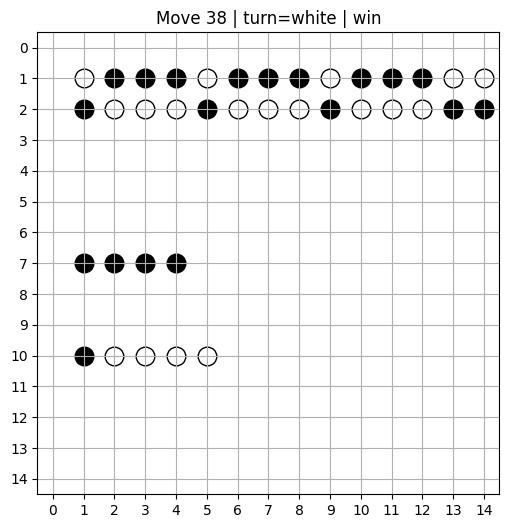

Game ended: win at move 38


('win', 38)

In [14]:
import time
import matplotlib.pyplot as plt
from IPython.display import clear_output, display


def board_to_absolute_stones(board_t, current_player=1):
    if current_player == 1:
        return board_t[0], board_t[1]
    return board_t[1], board_t[0]


def draw_board(board_t, move_number=0, current_player=1, reason="continue", pause=VISUAL_PAUSE):
    black, white = board_to_absolute_stones(board_t, current_player=current_player)
    board_size = board_t.shape[-1]

    clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(6, 6))

    ax.set_xlim(-0.5, board_size - 0.5)
    ax.set_ylim(board_size - 0.5, -0.5)
    ax.set_xticks(range(board_size))
    ax.set_yticks(range(board_size))
    ax.grid(True)
    ax.set_aspect("equal")
    ax.set_title(f"Move {move_number} | turn={'black' if current_player == 1 else 'white'} | {reason}")

    black_pos = torch.nonzero(black > 0.5, as_tuple=False)
    white_pos = torch.nonzero(white > 0.5, as_tuple=False)

    if black_pos.numel() > 0:
        ax.scatter(black_pos[:, 1].cpu(), black_pos[:, 0].cpu(), s=180, c="black", marker="o")
    if white_pos.numel() > 0:
        ax.scatter(white_pos[:, 1].cpu(), white_pos[:, 0].cpu(), s=180, c="white", edgecolors="black", marker="o")

    display(fig)
    plt.close(fig)
    time.sleep(pause)


def play_two_models_visual(model_black, model_white=None, max_moves=VISUAL_MAX_MOVES, pause=VISUAL_PAUSE):
    """
    Cho 2 model chơi thử và hiển thị bàn cờ theo thời gian thực.

    Nếu model_white=None thì dùng cùng model cho cả 2 bên.
    """
    if model_white is None:
        model_white = model_black

    device = next(model_black.parameters()).device
    board_t = create_empty_board(board_size=BOARD_SIZE, device=device)
    current_player = 1
    reason = "continue"

    model_black.eval()
    model_white.eval()

    draw_board(board_t, move_number=0, current_player=current_player, reason=reason, pause=pause)

    with torch.no_grad():
        for move_number in range(1, max_moves + 1):
            model = model_black if current_player == 1 else model_white
            scores_t = model(board_t.unsqueeze(0)).squeeze(0)
            next_board, reason = step_board_from_model_output(board_t, scores_t)

            if reason == "continue":
                board_t = next_board
                current_player *= -1
                draw_board(board_t, move_number=move_number, current_player=current_player, reason=reason, pause=pause)
                continue

            draw_board(board_t, move_number=move_number, current_player=current_player, reason=reason, pause=pause)
            print(f"Game ended: {reason} at move {move_number}")
            return reason, move_number

    print(f"Game ended: max_moves at move {max_moves}")
    return "max_moves", max_moves


# Chạy demo: nếu muốn chậm/nhanh hơn thì đổi VISUAL_PAUSE ở cell cấu hình.
play_two_models_visual(model)
